In [4]:
pip install fastf1

Note: you may need to restart the kernel to use updated packages.


In [6]:
import os
os.makedirs('f1_cache', exist_ok=True)

In [7]:
### importing the dataset 
import fastf1
import pandas as pd
import matplotlib.pyplot as plt

fastf1.Cache.enable_cache('f1_cache')

# Load 2023 Australian GP 
session = fastf1.get_session(2023, 'Australia', 'R')
session.event['EventName']




'Australian Grand Prix'

In [9]:
### load the data
session.load()
laps = session.laps
laps.head

core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.1]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No

<bound method NDFrame.head of                        Time Driver DriverNumber                LapTime  \
0    0 days 01:03:58.671000    VER            1 0 days 00:01:41.571000   
1    0 days 01:06:10.776000    VER            1 0 days 00:02:12.105000   
2    0 days 01:08:21.433000    VER            1 0 days 00:02:10.657000   
3    0 days 01:09:44.824000    VER            1 0 days 00:01:23.391000   
4    0 days 01:11:07.928000    VER            1 0 days 00:01:23.104000   
...                     ...    ...          ...                    ...   
998  0 days 02:39:23.012000    PIA           81 0 days 00:02:02.932000   
999  0 days 02:55:41.516000    PIA           81                    NaT   
1000 0 days 02:59:02.357000    PIA           81                    NaT   
1001 0 days 03:32:22.694000    PIA           81                    NaT   
1002 0 days 03:35:00.864000    PIA           81                    NaT   

      LapNumber  Stint             PitOutTime              PitInTime  \
0        

In [10]:
laps_df = pd.DataFrame(laps)
pd.set_option('display.max_columns', None)
laps_df.head(5)


,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,Sector3Time,Sector1SessionTime,Sector2SessionTime,Sector3SessionTime,SpeedI1,SpeedI2,SpeedFL,SpeedST,IsPersonalBest,Compound,TyreLife,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
0,0 days 01:03:58.671000,VER,1,0 days 00:01:41.571000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:18.707000,0 days 00:00:46.357000,NaT,0 days 01:03:12.425000,0 days 01:03:58.784000,274.0,293.0,273.0,239.0,False,MEDIUM,1.0,True,Red Bull Racing,0 days 01:02:16.863000,2023-04-02 05:03:18.685,124,3.0,False,,False,False
1,0 days 01:06:10.776000,VER,1,0 days 00:02:12.105000,2.0,1.0,NaT,NaT,0 days 00:00:48.846000,0 days 00:00:31.614000,0 days 00:00:51.645000,0 days 01:04:47.578000,0 days 01:05:19.192000,0 days 01:06:10.837000,167.0,107.0,253.0,93.0,True,MEDIUM,2.0,True,Red Bull Racing,0 days 01:03:58.671000,2023-04-02 05:05:00.493,4,3.0,False,,False,False
2,0 days 01:08:21.433000,VER,1,0 days 00:02:10.657000,3.0,1.0,NaT,NaT,0 days 00:00:46.836000,0 days 00:00:29.178000,0 days 00:00:54.643000,0 days 01:06:57.673000,0 days 01:07:26.851000,0 days 01:08:21.494000,204.0,162.0,289.0,133.0,True,MEDIUM,3.0,True,Red Bull Racing,0 days 01:06:10.776000,2023-04-02 05:07:12.598,41,3.0,False,,False,False
3,0 days 01:09:44.824000,VER,1,0 days 00:01:23.391000,4.0,1.0,NaT,NaT,0 days 00:00:28.900000,0 days 00:00:18.326000,0 days 00:00:36.165000,0 days 01:08:50.394000,0 days 01:09:08.720000,0 days 01:09:44.885000,280.0,296.0,288.0,303.0,True,MEDIUM,4.0,True,Red Bull Racing,0 days 01:08:21.433000,2023-04-02 05:09:23.255,1,3.0,False,,False,True
4,0 days 01:11:07.928000,VER,1,0 days 00:01:23.104000,5.0,1.0,NaT,NaT,0 days 00:00:28.935000,0 days 00:00:18.347000,0 days 00:00:35.822000,0 days 01:10:13.820000,0 days 01:10:32.167000,0 days 01:11:07.989000,273.0,294.0,290.0,286.0,True,MEDIUM,5.0,True,Red Bull Racing,0 days 01:09:44.824000,2023-04-02 05:10:46.646,1,3.0,False,,False,True


In [11]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [12]:
print(laps_df.columns.tolist())

['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint', 'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time', 'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest', 'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime', 'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason', 'FastF1Generated', 'IsAccurate']


In [13]:
print(laps_df.shape)
print(laps.dtypes)

(1003, 31)
Time                  timedelta64[ns]
Driver                         object
DriverNumber                   object
LapTime               timedelta64[ns]
LapNumber                     float64
Stint                         float64
PitOutTime            timedelta64[ns]
PitInTime             timedelta64[ns]
Sector1Time           timedelta64[ns]
Sector2Time           timedelta64[ns]
Sector3Time           timedelta64[ns]
Sector1SessionTime    timedelta64[ns]
Sector2SessionTime    timedelta64[ns]
Sector3SessionTime    timedelta64[ns]
SpeedI1                       float64
SpeedI2                       float64
SpeedFL                       float64
SpeedST                       float64
IsPersonalBest                 object
Compound                       object
TyreLife                      float64
FreshTyre                        bool
Team                           object
LapStartTime          timedelta64[ns]
LapStartDate           datetime64[ns]
TrackStatus                    object
P

In [14]:
laps_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1003 entries, 0 to 1002
Data columns (total 31 columns):
 #   Column              Non-Null Count  Dtype          
---  ------              --------------  -----          
 0   Time                1003 non-null   timedelta64[ns]
 1   Driver              1003 non-null   object         
 2   DriverNumber        1003 non-null   object         
 3   LapTime             901 non-null    timedelta64[ns]
 4   LapNumber           1003 non-null   float64        
 5   Stint               1003 non-null   float64        
 6   PitOutTime          67 non-null     timedelta64[ns]
 7   PitInTime           65 non-null     timedelta64[ns]
 8   Sector1Time         968 non-null    timedelta64[ns]
 9   Sector2Time         995 non-null    timedelta64[ns]
 10  Sector3Time         932 non-null    timedelta64[ns]
 11  Sector1SessionTime  966 non-null    timedelta64[ns]
 12  Sector2SessionTime  995 non-null    timedelta64[ns]
 13  Sector3SessionTime  932 non-null 

In [15]:
laps_df.isnull().sum()

Time                    0
Driver                  0
DriverNumber            0
LapTime               102
LapNumber               0
Stint                   0
PitOutTime            936
PitInTime             938
Sector1Time            35
Sector2Time             8
Sector3Time            71
Sector1SessionTime     37
Sector2SessionTime      8
Sector3SessionTime     71
SpeedI1                 8
SpeedI2                 8
SpeedFL                73
SpeedST                 8
IsPersonalBest          7
Compound                0
TyreLife                0
FreshTyre               0
Team                    0
LapStartTime            0
LapStartDate            7
TrackStatus             0
Position                8
Deleted                 0
DeletedReason           7
FastF1Generated         0
IsAccurate              0
dtype: int64

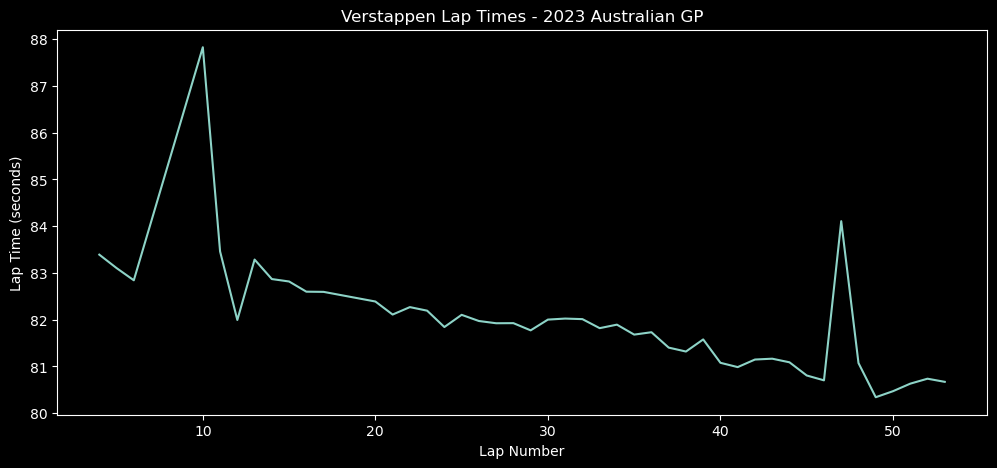

In [16]:
# Convert LapTime to seconds for easier plotting
laps_df['LapTimeSeconds'] = laps_df['LapTime'].dt.total_seconds()

# Filter clean laps only
clean_laps = laps_df[laps_df['IsAccurate'] == True]

# Get Verstappen's laps
ver_laps = clean_laps[clean_laps['Driver'] == 'VER']

# Plot
plt.figure(figsize=(12, 5))
plt.plot(ver_laps['LapNumber'], ver_laps['LapTimeSeconds'])
plt.xlabel('Lap Number')
plt.ylabel('Lap Time (seconds)')
plt.title('Verstappen Lap Times - 2023 Australian GP')
plt.show()

/opt/anaconda3/lib/python3.13/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
/var/folders/9p/2_yj6s3j20l9v41g9zzslq4r0000gn/T/ipykernel_65040/1822836846.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ver_laps['LapTimeSeconds'] = ver_laps['LapTime'].dt.total_seconds()


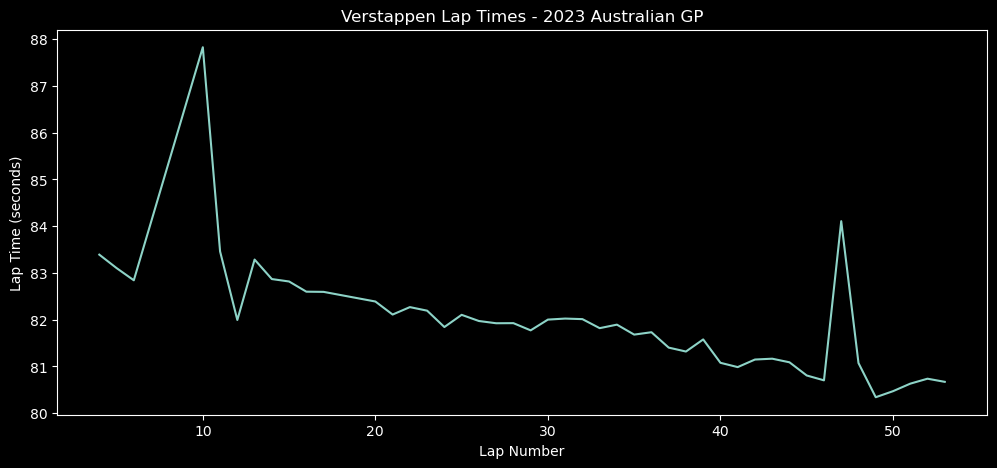

In [17]:
# fastf1 has built in methods - much cleaner
ver_laps = session.laps.pick_driver('VER').pick_accurate()
ver_laps['LapTimeSeconds'] = ver_laps['LapTime'].dt.total_seconds()

plt.figure(figsize=(12, 5))
plt.plot(ver_laps['LapNumber'], ver_laps['LapTimeSeconds'])
plt.xlabel('Lap Number')
plt.ylabel('Lap Time (seconds)')
plt.title('Verstappen Lap Times - 2023 Australian GP')
plt.show()

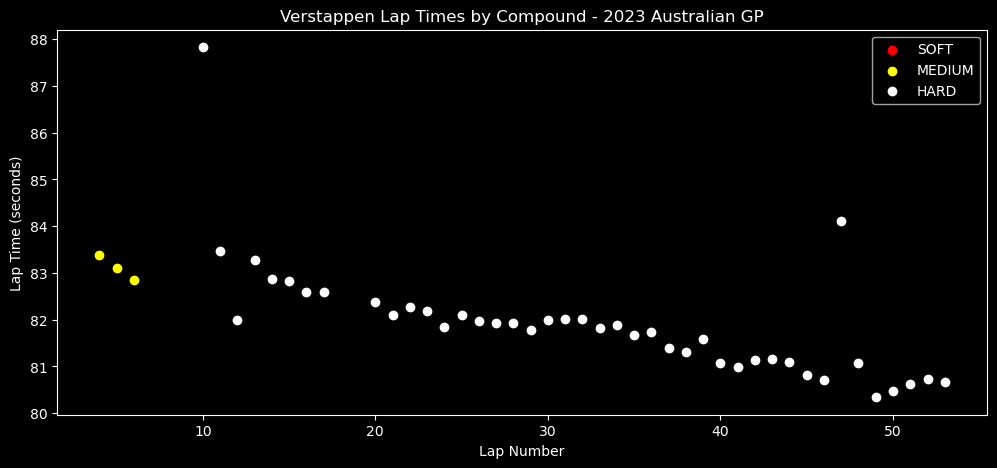

In [18]:
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(12, 5))

soft_laps = ver_laps.pick_compounds('SOFT')
medium_laps = ver_laps.pick_compounds('MEDIUM')
hard_laps = ver_laps.pick_compounds('HARD')

ax.scatter(soft_laps['LapNumber'], soft_laps['LapTimeSeconds'], color='red', label='SOFT')
ax.scatter(medium_laps['LapNumber'], medium_laps['LapTimeSeconds'], color='yellow', label='MEDIUM')
ax.scatter(hard_laps['LapNumber'], hard_laps['LapTimeSeconds'], color='white', label='HARD')
ax.set_xlabel('Lap Number')
ax.set_ylabel('Lap Time (seconds)')
ax.set_title('Verstappen Lap Times by Compound - 2023 Australian GP')
ax.legend()
plt.show()

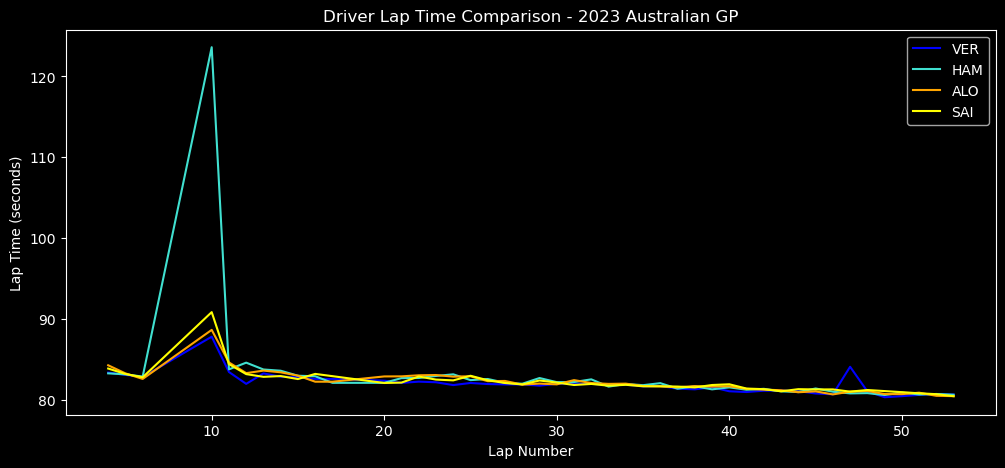

In [19]:
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(12, 5))
driver_colors = {
    'VER': 'blue',
    'HAM': 'turquoise',
    'ALO': 'orange',
    'SAI': 'yellow'
}

for driver, color in driver_colors.items():
    driver_laps = session.laps.pick_drivers(driver).pick_accurate().copy()
    driver_laps['LapTimeSeconds'] = driver_laps['LapTime'].dt.total_seconds()
    ax.plot(driver_laps['LapNumber'], driver_laps['LapTimeSeconds'],
               label=driver, color=color)
ax.set_xlabel('Lap Number')
ax.set_ylabel('Lap Time (seconds)')
ax.set_title('Driver Lap Time Comparison - 2023 Australian GP')
ax.legend()

plt.show()

In [20]:
ver_laps

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,Sector3Time,Sector1SessionTime,Sector2SessionTime,Sector3SessionTime,SpeedI1,SpeedI2,SpeedFL,SpeedST,IsPersonalBest,Compound,TyreLife,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate,LapTimeSeconds
3,0 days 01:09:44.824000,VER,1,0 days 00:01:23.391000,4.0,1.0,NaT,NaT,0 days 00:00:28.900000,0 days 00:00:18.326000,0 days 00:00:36.165000,0 days 01:08:50.394000,0 days 01:09:08.720000,0 days 01:09:44.885000,280.0,296.0,288.0,303.0,True,MEDIUM,4.0,True,Red Bull Racing,0 days 01:08:21.433000,2023-04-02 05:09:23.255,1,3.0,False,,False,True,83.391
4,0 days 01:11:07.928000,VER,1,0 days 00:01:23.104000,5.0,1.0,NaT,NaT,0 days 00:00:28.935000,0 days 00:00:18.347000,0 days 00:00:35.822000,0 days 01:10:13.820000,0 days 01:10:32.167000,0 days 01:11:07.989000,273.0,294.0,290.0,286.0,True,MEDIUM,5.0,True,Red Bull Racing,0 days 01:09:44.824000,2023-04-02 05:10:46.646,1,3.0,False,,False,True,83.104
5,0 days 01:12:30.771000,VER,1,0 days 00:01:22.843000,6.0,1.0,NaT,NaT,0 days 00:00:28.986000,0 days 00:00:17.951000,0 days 00:00:35.906000,0 days 01:11:36.975000,0 days 01:11:54.926000,0 days 01:12:30.832000,276.0,322.0,304.0,296.0,True,MEDIUM,6.0,True,Red Bull Racing,0 days 01:11:07.928000,2023-04-02 05:12:09.750,1,3.0,False,,False,True,82.843
9,0 days 01:37:16.003000,VER,1,0 days 00:01:27.827000,10.0,2.0,NaT,NaT,0 days 00:00:33.323000,0 days 00:00:18.633000,0 days 00:00:35.871000,0 days 01:36:21.560000,0 days 01:36:40.193000,0 days 01:37:16.064000,276.0,288.0,288.0,242.0,False,HARD,2.0,True,Red Bull Racing,0 days 01:35:48.176000,2023-04-02 05:36:49.998,1,2.0,False,,False,True,87.827
10,0 days 01:38:39.463000,VER,1,0 days 00:01:23.460000,11.0,2.0,NaT,NaT,0 days 00:00:29.054000,0 days 00:00:18.556000,0 days 00:00:35.850000,0 days 01:37:45.118000,0 days 01:38:03.674000,0 days 01:38:39.524000,270.0,292.0,289.0,288.0,False,HARD,3.0,True,Red Bull Racing,0 days 01:37:16.003000,2023-04-02 05:38:17.825,1,2.0,False,,False,True,83.460
11,0 days 01:40:01.457000,VER,1,0 days 00:01:21.994000,12.0,2.0,NaT,NaT,0 days 00:00:28.827000,0 days 00:00:18.134000,0 days 00:00:35.033000,0 days 01:39:08.351000,0 days 01:39:26.485000,0 days 01:40:01.518000,281.0,321.0,287.0,293.0,True,HARD,4.0,True,Red Bull Racing,0 days 01:38:39.463000,2023-04-02 05:39:41.285,1,1.0,False,,False,True,81.994
12,0 days 01:41:24.743000,VER,1,0 days 00:01:23.286000,13.0,2.0,NaT,NaT,0 days 00:00:28.876000,0 days 00:00:18.642000,0 days 00:00:35.768000,0 days 01:40:30.394000,0 days 01:40:49.036000,0 days 01:41:24.804000,272.0,287.0,286.0,281.0,False,HARD,5.0,True,Red Bull Racing,0 days 01:40:01.457000,2023-04-02 05:41:03.279,1,1.0,False,,False,True,83.286
13,0 days 01:42:47.612000,VER,1,0 days 00:01:22.869000,14.0,2.0,NaT,NaT,0 days 00:00:28.769000,0 days 00:00:18.604000,0 days 00:00:35.496000,0 days 01:41:53.573000,0 days 01:42:12.177000,0 days 01:42:47.673000,275.0,290.0,287.0,293.0,False,HARD,6.0,True,Red Bull Racing,0 days 01:41:24.743000,2023-04-02 05:42:26.565,1,1.0,False,,False,True,82.869
14,0 days 01:44:10.429000,VER,1,0 days 00:01:22.817000,15.0,2.0,NaT,NaT,0 days 00:00:28.785000,0 days 00:00:18.527000,0 days 00:00:35.505000,0 days 01:43:16.458000,0 days 01:43:34.985000,0 days 01:44:10.490000,274.0,290.0,286.0,290.0,False,HARD,7.0,True,Red Bull Racing,0 days 01:42:47.612000,2023-04-02 05:43:49.434,1,1.0,False,,False,True,82.817
15,0 days 01:45:33.028000,VER,1,0 days 00:01:22.599000,16.0,2.0,NaT,NaT,0 days 00:00:28.696000,0 days 00:00:18.502000,0 days 00:00:35.401000,0 days 01:44:39.186000,0 days 01:44:57.688000,0 days 01:45:33.089000,276.0,291.0,286.0,292.0,False,HARD,8.0,True,Red Bull Racing,0 days 01:44:10.429000,2023-04-02 05:45:12.251,1,1.0,False,,False,True,82.599


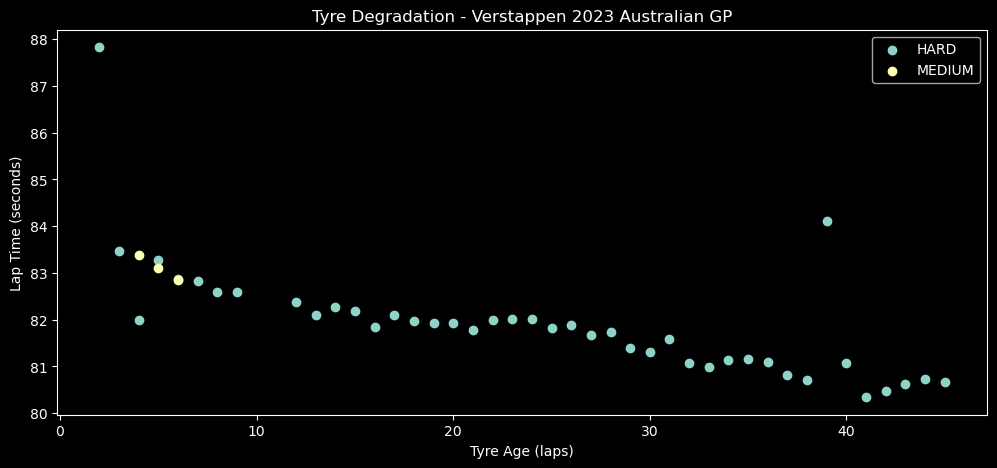

In [42]:
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(12, 5))
groups = ver_laps.groupby('Compound')

ver_laps['TyreLife'] = ver_laps['TyreLife'].astype(int)

for name,group in groups:
    ax.scatter(group['TyreLife'],group['LapTimeSeconds'],label=name)

ax.set_xlabel('Tyre Age (laps)')
ax.set_ylabel('Lap Time (seconds)')
ax.set_title('Tyre Degradation - Verstappen 2023 Australian GP')
ax.legend()
plt.show()

In [44]:
groups = ver_laps.groupby('Compound')

for name, group in groups:
    print(f"Compound: {name}")
    print(f"Number of laps: {len(group)}")
    print(group[['LapNumber', 'TyreLife', 'LapTimeSeconds']].head(3))
    print("---")


Compound: HARD
Number of laps: 42
    LapNumber  TyreLife  LapTimeSeconds
9        10.0         2          87.827
10       11.0         3          83.460
11       12.0         4          81.994
---
Compound: MEDIUM
Number of laps: 3
   LapNumber  TyreLife  LapTimeSeconds
3        4.0         4          83.391
4        5.0         5          83.104
5        6.0         6          82.843
---


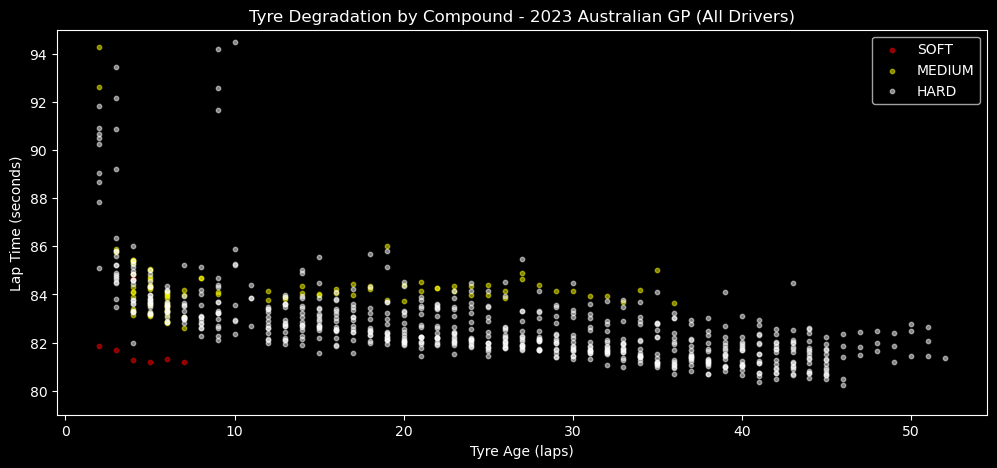

In [25]:
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(12, 5))

compound_colors = {
    'SOFT': 'red',
    'MEDIUM': 'yellow',
    'HARD': 'white'
}

all_laps = session.laps.pick_accurate().copy()
all_laps['LapTimeSeconds'] = all_laps['LapTime'].dt.total_seconds()

for compound, color in compound_colors.items():
    compound_laps = all_laps.pick_compounds(compound)
    ax.scatter(compound_laps['TyreLife'], compound_laps['LapTimeSeconds'],
               color=color, label=compound, s=10, alpha=0.5)

ax.set_xlabel('Tyre Age (laps)')
ax.set_ylabel('Lap Time (seconds)')
ax.set_title('Tyre Degradation by Compound - 2023 Australian GP (All Drivers)')
ax.set_ylim(79, 95)
ax.legend()
plt.show()

In [24]:
pit_laps = laps_df[laps_df['PitInTime'].notna()]

NameError: name 'compund_laps' is not defined

In [26]:
pit_laps = laps_df[laps_df['PitInTime'].notna()]

In [27]:
pit_laps[['Driver', 'LapNumber', 'PitInTime', 'PitOutTime']]

,Driver,LapNumber,PitInTime,PitOutTime
7,VER,8.0,0 days 01:16:44.650000,NaT
54,VER,55.0,0 days 02:40:37.639000,NaT
56,VER,57.0,0 days 03:01:08.797000,NaT
65,GAS,8.0,0 days 01:16:52.150000,NaT
112,GAS,55.0,0 days 02:40:46.560000,NaT
115,PER,1.0,0 days 01:04:13.705000,0 days 01:02:25.722000
116,PER,2.0,0 days 01:06:25.251000,0 days 01:04:31.424000
122,PER,8.0,0 days 01:17:15.352000,NaT
169,PER,55.0,0 days 02:40:51.795000,NaT
171,PER,57.0,0 days 03:01:24.453000,NaT


In [29]:
actual_pitstops = laps_df[laps_df['PitInTime'].notna() & laps_df['PitOutTime'].notna()]
actual_pitstops = actual_pitstops.copy()
actual_pitstops['PitStopDuration'] = actual_pitstops['PitInTime'] - actual_pitstops['PitOutTime']
actual_pitstops['PitStopSeconds'] = actual_pitstops['PitStopDuration'].dt.total_seconds()

print(actual_pitstops[['Driver', 'LapNumber', 'PitStopSeconds']])

    Driver  LapNumber  PitStopSeconds
115    PER        1.0         107.983
116    PER        2.0         113.827
291    SAR        2.0         113.952
344    SAR       55.0          98.311
354    MAG        8.0         164.951
454    DEV       55.0         100.046
511    TSU       55.0         117.546
576    ZHO       55.0         114.452
818    SAI        8.0         164.467
876    RUS        8.0         159.420
887    BOT        1.0         107.780
940    BOT       54.0         141.123
941    BOT       55.0          97.030
999    PIA       55.0         114.108


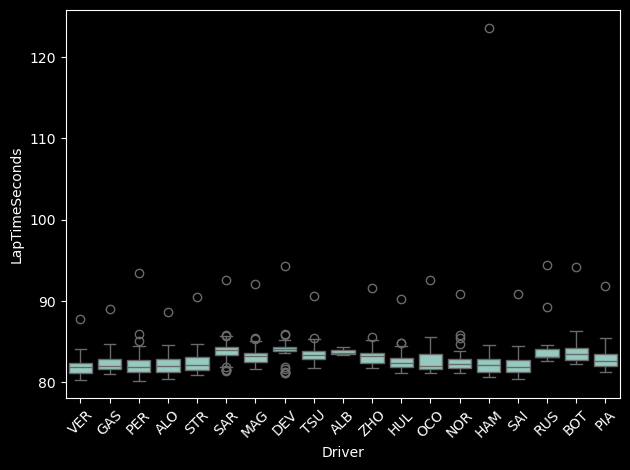

In [34]:
import seaborn as sns
sns.boxplot(x='Driver', y='LapTimeSeconds', data=all_laps)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

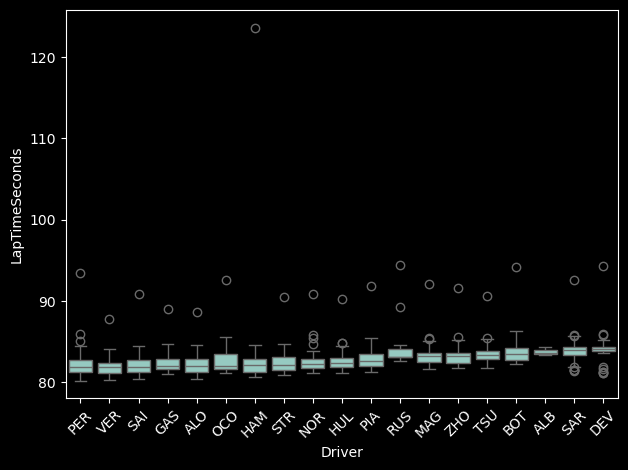

In [36]:
order = all_laps.groupby('Driver')['LapTimeSeconds'].median().sort_values().index
sns.boxplot(x='Driver', y='LapTimeSeconds', data=all_laps, order=order)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [37]:
numeric_cols = all_laps[['LapTimeSeconds', 'TyreLife', 'LapNumber', 'Stint', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST']].copy()
numeric_cols.corr()

,LapTimeSeconds,TyreLife,LapNumber,Stint,SpeedI1,SpeedI2,SpeedFL,SpeedST
LapTimeSeconds,1.000000,-0.488377,-0.512154,-0.004560,-0.478298,0.098923,-0.190244,-0.476451
TyreLife,-0.488377,1.000000,0.920257,0.122941,0.377913,-0.309565,0.002076,0.078090
LapNumber,-0.512154,0.920257,1.000000,0.215849,0.434386,-0.301249,0.008470,0.111030
Stint,-0.004560,0.122941,0.215849,1.000000,0.090813,0.277427,0.132460,0.132895
SpeedI1,-0.478298,0.377913,0.434386,0.090813,1.000000,0.034360,0.059180,0.345556
SpeedI2,0.098923,-0.309565,-0.301249,0.277427,0.034360,1.000000,0.491644,0.481386
SpeedFL,-0.190244,0.002076,0.008470,0.132460,0.059180,0.491644,1.000000,0.341153
SpeedST,-0.476451,0.078090,0.111030,0.132895,0.345556,0.481386,0.341153,1.000000


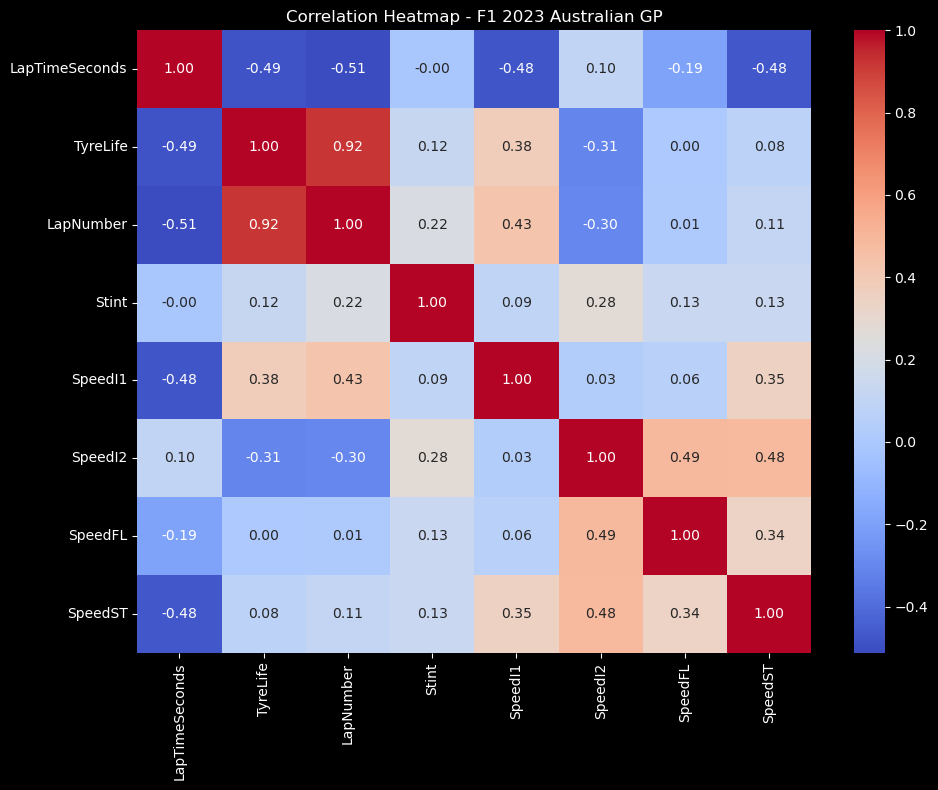

In [38]:
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 8))

numeric_cols = ['LapTimeSeconds', 'TyreLife', 'LapNumber', 'Stint', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST']
corr_matrix = all_laps[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
ax.set_title('Correlation Heatmap - F1 2023 Australian GP')
plt.tight_layout()
plt.show()